# 02e — Mid-level PLS + Random Forest fusion classifier

**CAC2026 Data Challenge — olive oil musty-defect detection (scored by F1).**

Same mid-level data-fusion pipeline, with a **Random Forest** head on the fused
PLS scores — a non-linear, non-parametric, axis-aligned-split classifier:

```
X_hsms ──PLS-DA(LV)──► T_hsms ┐
X_mir  ──PLS-DA(LV)──► T_mir  ├─ hstack ─► RandomForest ─► musty / not-musty
X_uvvis──PLS-DA(LV)──► T_uvvis┘
```

Two things specific to this setup shape the grid:

1. **The input is the low-dimensional fused PLS scores** (~16–31 dense, already
   class-relevant features), not raw spectra — so heavy feature subsampling isn't
   needed and `max_features` actually matters (few, informative features).
2. **`scale_fused` is irrelevant** — trees split on thresholds, so RF is invariant
   to feature scaling. It is **fixed to `False`**, not searched.

> References so far — 02a PLS-DA **0.765**, 02b LDA **0.755**, 02c QDA **0.688**,
> 02d SVM-RBF **0.777** (current best).

In [1]:
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
)

# Quiet sklearn's convergence / undefined-metric chatter during the CV sweeps.
warnings.filterwarnings("ignore")

from olive_oil import (
    load_dataset,
    BlockConfig,
    prepare_blocks,
    MidLevelFusionClassifier,
    nested_cv,
    tune_final_model,
    predict_test,
    make_cv,
)
from olive_oil.visualization import plot_spectra

# Resolve the project root whether the notebook runs from Notebooks/ or the root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "CAC2026_Data_challenge.xlsx"
DATA_PATH

WindowsPath('C:/Users/SamdGuizani/OneDrive/Documents/Data Science & Coding/2026-Olive Oil Classification (CAC 2026)/CAC-2026_Data-Challenge_Olive-Oil-Sensory-Defects-Detection-Using-Chemometrics/Data/CAC2026_Data_challenge.xlsx')

## 1. Load the data

In [2]:
raw = load_dataset(DATA_PATH)
labels = raw["labels"]
print("Calibration samples:", labels.shape[0])
print("Class balance (0 = not musty, 1 = musty):",
      labels["label"].value_counts().sort_index().to_dict())
print("Musty prevalence:", round(labels["label"].mean(), 3))

Calibration samples: 220
Class balance (0 = not musty, 1 = musty): {0: 144, 1: 76}
Musty prevalence: 0.345


## 2. Configure the blocks

Identical block windows / preprocessing to 02a–02d (clean classifier comparison).

In [3]:
# Per-block spectral window + preprocessing recipe (same as 02a best run).
configs = {
    "hsms": BlockConfig(
        region=(100, 125),
        steps=["row_profile", "log", "mean_center"],
    ),
    "mir": BlockConfig(
        region=(1500, 700),
        steps=["snv",
               ("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 6}),
               "mean_center"],
    ),
    "uvvis": BlockConfig(
        region=(300, 1000),
        steps=["snv",
               ("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 6}),
               "mean_center"],
    ),
}

# Calibration sample IDs to discard as outliers (default: none).
outliers = []

data = prepare_blocks(raw, configs, outliers=outliers)
print("Discarded outliers:", data.discarded_ids or "none")
print("Block order:", data.block_names)
data.summary()

Discarded outliers: none
Block order: ['hsms', 'mir', 'uvvis']


,n_variables,axis_min,axis_max,n_train,n_test
block,,,,,
hsms,26,100.00000,125.000000,220,24
mir,208,700.04498,1498.443334,220,24
uvvis,701,300.00000,1000.000000,220,24


### Sanity-check the preprocessed spectra (optional)

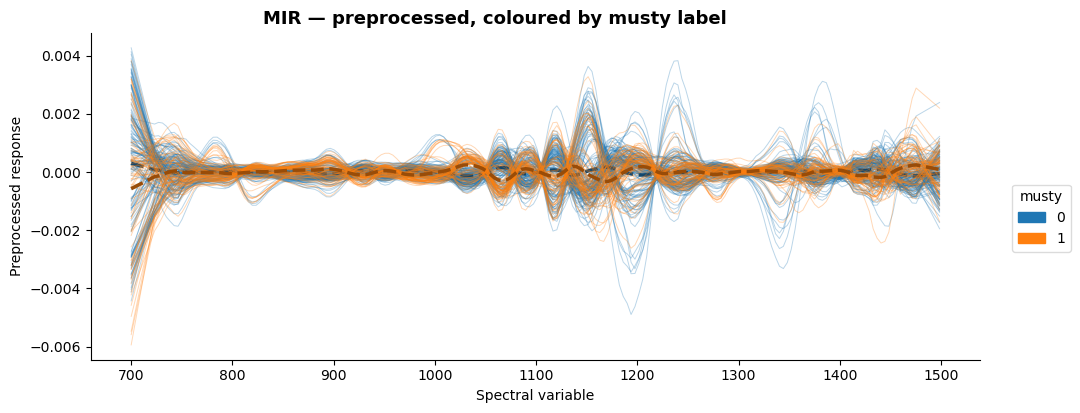

In [4]:
block = "mir"  # try "hsms" / "uvvis" too
i = data.block_names.index(block)
spectra = (data.X_train[i], data.axes[block], data.train_ids)
label_meta = raw["labels"].rename(columns={"label": "musty"})

g = plot_spectra(
    spectra, metadata=label_meta, color_by="musty",
    xlabel="Spectral variable", ylabel="Preprocessed response",
    title=f"{block.upper()} — preprocessed, coloured by musty label",
)

## 3. Build the coarse hyperparameter grid

`n_estimators` is fixed at 300 (more trees only stabilises averaging, it is not a
performance lever), and the **block tuples are trimmed for speed** — HS-MS is
fixed at 4 (it has been irrelevant in every prior notebook), and only the
signal-bearing MIR/UV-vis ranges are swept:

| Hyperparameter | Meaning | Coarse range |
|---|---|---|
| `n_components_list` (block LVs) | HS-MS × MIR × UV-vis | `4 × {9,15,21} × {9,12}` |
| `classifier__max_depth` | tree depth (regularisation) | `None, 6, 12` |
| `classifier__min_samples_leaf` | min samples per leaf | `1, 5` |
| `classifier__max_features` | features considered per split | `sqrt, 0.5` |
| `classifier__class_weight` | class imbalance handling | `None, balanced` |

`max_depth` and `min_samples_leaf` are the regularisers that matter most at
n = 220; `class_weight="balanced"` is the knob most likely to shift the
precision/recall balance under the ~34 % musty imbalance.

In [5]:
# Trimmed block tuples: HS-MS fixed (always irrelevant), MIR/UV swept.
LV_HSMS  = (4,)
LV_MIR   = (9, 15, 21)
LV_UVVIS = (9, 12)

component_grid = [tuple(t) for t in product(LV_HSMS, LV_MIR, LV_UVVIS)]

param_grid = {
    "n_components_list": component_grid,
    "classifier__max_depth": [None, 6, 12],
    "classifier__min_samples_leaf": [1, 5],
    "classifier__max_features": ["sqrt", 0.5],
    "classifier__class_weight": [None, "balanced"],
}

n_configs = (len(component_grid) * 3 * 2 * 2 * 2)
print(f"Component tuples : {len(component_grid)}  ->", component_grid)
print(f"Total configs    : {n_configs}")
print(f"Nested fits total: ~{n_configs*3*5} (5 outer folds) x 300 trees each")

Component tuples : 6  -> [(4, 9, 9), (4, 9, 12), (4, 15, 9), (4, 15, 12), (4, 21, 9), (4, 21, 12)]
Total configs    : 144
Nested fits total: ~2160 (5 outer folds) x 300 trees each


## 4. Define the model

Random Forest head. `n_jobs=1` on the forest so the outer/inner `GridSearchCV`
(`n_jobs=-1`) owns the cores without oversubscription. `scale_fused=False` is
fixed — RF is scale-invariant, so there is nothing to gain by searching it.

In [6]:
model = MidLevelFusionClassifier(
    classifier=RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=1),
    scale_fused=False,   # RF is scale-invariant -> fixed, not searched
)

## 5. Nested cross-validation — the honest F1 estimate

Inner `GridSearchCV` (3-fold) tunes the grid on each outer training split; outer
`cross_validate` (5-fold) scores F1/precision/recall on the held-out outer fold.

In [7]:
nested = nested_cv(
    model, param_grid,
    data.train_blocks(), data.y,
    outer_cv=make_cv(5, random_state=0),
    inner_cv=make_cv(3, random_state=1),
)

print("Outer-fold performance (mean ± std):")
display(nested["summary"].round(3))

f1 = nested["raw"]["test_f1"]
coarse_nested_f1 = f1.mean()
print("Per-fold F1:", np.round(f1, 3))
print(f"Nested-CV F1 (coarse grid): {f1.mean():.3f} +/- {f1.std():.3f}")
print("\nWinning hyperparameters per outer fold:")
for k, p in enumerate(nested["best_params"]):
    print(f"  fold {k}: {p}")

Outer-fold performance (mean ± std):


,test_mean,test_std,train_mean,train_std
metric,,,,
f1,0.775,0.045,0.970,0.034
precision,0.778,0.047,0.974,0.030
recall,0.776,0.069,0.967,0.045


Per-fold F1: [0.774 0.812 0.786 0.69  0.812]
Nested-CV F1 (coarse grid): 0.775 +/- 0.045

Winning hyperparameters per outer fold:
  fold 0: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'n_components_list': (4, 9, 9)}
  fold 1: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 6, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 1, 'n_components_list': (4, 9, 9)}
  fold 2: {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'n_components_list': (4, 9, 9)}
  fold 3: {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'n_components_list': (4, 15, 12)}
  fold 4: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 6, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 1, 'n_co

## 6. Refit on all calibration data (coarse grid)

In [8]:
search = tune_final_model(
    model, param_grid,
    data.train_blocks(), data.y,
    cv=make_cv(5, random_state=0),
)
print("Best hyperparameters:", search.best_params_)
print("Best inner-CV F1     :", round(search.best_score_, 3))

Best hyperparameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'n_components_list': (4, 15, 9)}
Best inner-CV F1     : 0.799


## 7. Explore the search landscape

The depth × leaf-size surface shows the regularisation trade-off; the
`class_weight` summary highlights the imbalance knob.

In [9]:
res = pd.DataFrame(search.cv_results_)
lv = pd.DataFrame(res["param_n_components_list"].tolist(),
                  index=res.index, columns=["lv_hsms", "lv_mir", "lv_uvvis"])
res = pd.concat([res, lv], axis=1)
res["max_depth"] = res["param_classifier__max_depth"].astype(str)
res["min_leaf"] = res["param_classifier__min_samples_leaf"]
res["max_features"] = res["param_classifier__max_features"].astype(str)
res["class_weight"] = res["param_classifier__class_weight"].astype(str)

show_cols = ["lv_mir", "lv_uvvis", "max_depth", "min_leaf", "max_features",
             "class_weight", "mean_test_score", "std_test_score", "rank_test_score"]
print("Top 15 configurations by mean CV F1:")
display(res.sort_values("rank_test_score")[show_cols].head(15).round(3).reset_index(drop=True))

print("\nBest mean CV F1 by class_weight:")
print(res.groupby("class_weight")["mean_test_score"].max().round(3).to_dict())
print("Best mean CV F1 by max_features:")
print(res.groupby("max_features")["mean_test_score"].max().round(3).to_dict())

Top 15 configurations by mean CV F1:


,lv_mir,lv_uvvis,max_depth,min_leaf,max_features,class_weight,mean_test_score,std_test_score,rank_test_score
0,15,9,6,5,0.5,balanced,0.799,0.069,1
1,15,9,NaN,5,0.5,balanced,0.799,0.069,1
2,15,9,12,5,0.5,balanced,0.799,0.069,1
3,9,12,NaN,5,0.5,balanced,0.795,0.069,4
4,9,12,12,5,0.5,balanced,0.795,0.069,4
5,9,12,6,5,0.5,balanced,0.795,0.069,4
6,15,9,NaN,5,sqrt,balanced,0.793,0.041,7
7,9,9,NaN,5,sqrt,balanced,0.793,0.041,7
8,9,9,12,5,sqrt,balanced,0.793,0.041,7
9,15,9,12,5,sqrt,balanced,0.793,0.041,7



Best mean CV F1 by class_weight:
{'balanced': 0.799}
Best mean CV F1 by max_features:
{'0.5': 0.799, 'sqrt': 0.793}


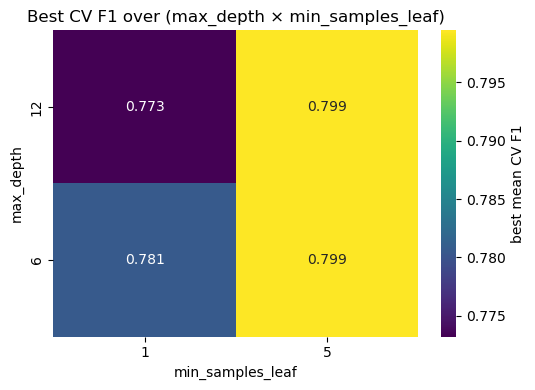

In [10]:
# Heatmap: best CV F1 for each (max_depth, min_samples_leaf) pair (max over others).
piv = res.pivot_table(index="max_depth", columns="min_leaf",
                      values="mean_test_score", aggfunc="max")
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            cbar_kws={"label": "best mean CV F1"})
ax.set_title("Best CV F1 over (max_depth × min_samples_leaf)")
ax.set_xlabel("min_samples_leaf"); ax.set_ylabel("max_depth")
plt.tight_layout(); plt.show()

## 8. Fine grid around the coarse winner (optional refinement)

Refine the block latent variables in a ±1 neighbourhood of the coarse winner,
**locking** the winning RF hyperparameters. Nested CV is re-run to keep the
comparison honest.

In [11]:
def neighbours(value, lo, hi, span=1):
    return sorted({max(lo, min(hi, value + d)) for d in range(-span, span + 1)})

best = search.best_params_
b_hsms, b_mir, b_uvvis = best["n_components_list"]

fine_components = [
    tuple(t) for t in product(
        neighbours(b_hsms, 1, 14),
        neighbours(b_mir, 1, 28),
        neighbours(b_uvvis, 1, 18),
    )
]

fine_grid = {
    "n_components_list": fine_components,
    "classifier__max_depth": [best["classifier__max_depth"]],
    "classifier__min_samples_leaf": [best["classifier__min_samples_leaf"]],
    "classifier__max_features": [best["classifier__max_features"]],
    "classifier__class_weight": [best["classifier__class_weight"]],
}
print("Fine component tuples:", fine_components)
print("Locked RF params     :", {k: v for k, v in best.items() if k != "n_components_list"})
print("Fine configs         :", len(fine_components))

Fine component tuples: [(3, 14, 8), (3, 14, 9), (3, 14, 10), (3, 15, 8), (3, 15, 9), (3, 15, 10), (3, 16, 8), (3, 16, 9), (3, 16, 10), (4, 14, 8), (4, 14, 9), (4, 14, 10), (4, 15, 8), (4, 15, 9), (4, 15, 10), (4, 16, 8), (4, 16, 9), (4, 16, 10), (5, 14, 8), (5, 14, 9), (5, 14, 10), (5, 15, 8), (5, 15, 9), (5, 15, 10), (5, 16, 8), (5, 16, 9), (5, 16, 10)]
Locked RF params     : {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5}
Fine configs         : 27


In [12]:
nested_fine = nested_cv(
    model, fine_grid,
    data.train_blocks(), data.y,
    outer_cv=make_cv(5, random_state=0),
    inner_cv=make_cv(3, random_state=1),
)
fine_nested_f1 = nested_fine["raw"]["test_f1"].mean()

fine_search = tune_final_model(
    model, fine_grid, data.train_blocks(), data.y, cv=make_cv(5, random_state=0),
)

print(f"Coarse nested-CV F1: {coarse_nested_f1:.3f}")
print(f"Fine   nested-CV F1: {fine_nested_f1:.3f}")
print("Fine best params   :", fine_search.best_params_)

Coarse nested-CV F1: 0.775
Fine   nested-CV F1: 0.782
Fine best params   : {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'n_components_list': (3, 16, 9)}


## 9. Deploy the best model

Pick whichever grid gave the better **honest (nested)** F1; its `tune_final_model`
search is already refit on all calibration data.

In [13]:
if fine_nested_f1 >= coarse_nested_f1:
    final_search, tag, headline_f1 = fine_search, "fine", fine_nested_f1
else:
    final_search, tag, headline_f1 = search, "coarse", coarse_nested_f1

print(f"Deploying the {tag}-grid model "
      f"(nested-CV F1 = {headline_f1:.3f}; params = {final_search.best_params_})")

Deploying the fine-grid model (nested-CV F1 = 0.782; params = {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'n_components_list': (3, 16, 9)})


## 10. Training-set fit of the deployed model

Scores on the **calibration set it was fitted on** (resubstitution): F1, Precision,
Recall and Inaccuracy (% misclassified).

> Optimistic — the model has seen these samples. RF in particular fits training
> hard, so expect a large train/test gap; the honest estimate stays the nested-CV
> F1 (§5).

In [14]:
y_train_pred = final_search.predict(data.train_blocks())

train_scores = pd.DataFrame(
    {"train": [
        f1_score(data.y, y_train_pred),
        precision_score(data.y, y_train_pred),
        recall_score(data.y, y_train_pred),
        100.0 * (1.0 - accuracy_score(data.y, y_train_pred)),
    ]},
    index=["F1", "Precision", "Recall", "Inaccuracy (%)"],
)
print(f"Deployed model train-set fit (n = {len(data.y)} samples):")
display(train_scores.round(3))
print(f"For reference — honest nested-CV F1: {headline_f1:.3f}")

Deployed model train-set fit (n = 220 samples):


,train
F1,0.896
Precision,0.885
Recall,0.908
Inaccuracy (%),7.273


For reference — honest nested-CV F1: 0.782


## 11. Predict the test set

In [15]:
predictions = predict_test(final_search, data.test_blocks(), data.test_ids)
print("Predicted test balance:",
      predictions["prediction"].value_counts().sort_index().to_dict())

out_path = PROJECT_ROOT / "Data" / "predictions_02e_RF.csv"
predictions.to_csv(out_path, index=False)
print("Saved:", out_path)
predictions

Predicted test balance: {0: 16, 1: 8}
Saved: C:\Users\SamdGuizani\OneDrive\Documents\Data Science & Coding\2026-Olive Oil Classification (CAC 2026)\CAC-2026_Data-Challenge_Olive-Oil-Sensory-Defects-Detection-Using-Chemometrics\Data\predictions_02e_RF.csv


,sample_id,prediction,proba_musty
0,1,1,0.905140
1,2,0,0.072801
2,3,1,0.777220
3,4,0,0.290928
4,5,0,0.047525
5,6,0,0.058360
6,7,0,0.158989
7,8,1,0.672043
8,9,0,0.172785
9,10,0,0.149329


## 12. Which blocks drive the decision? (feature importances)

The RF head exposes importances on the 28 fused PLS scores. Mapping each fused
component back to its block tells us where the discriminative signal lives. We
report two views: **impurity** importance (fast, but biased toward
high-variance features) and **permutation** importance (re-scores F1 after
shuffling each feature — slower, less biased).

> **Key finding (and a correction).** HS-MS dominates — its first PLS component
> alone carries most of the signal. A *low* chosen HS-MS LV count earlier did
> **not** mean the block was irrelevant; it meant its signal is so concentrated
> that one component captures it. This is chemically sensible: mustiness is an
> **aroma defect** and HS-MS measures the headspace volatiles directly. MIR and
> UV-vis are **complementary** (they still contribute), so the fusion is justified,
> but HS-MS is the anchor — do not drop it, and prioritise its region/preprocessing.

In [16]:
from sklearn.inspection import permutation_importance

deployed = final_search.best_estimator_          # MidLevelFusionClassifier, refit on all data
ncl = deployed.n_components_list                  # (n_hsms, n_mir, n_uvvis)

# Map each fused column back to its block + within-block component index.
col_block, col_lv = [], []
for b, n in zip(data.block_names, ncl):
    col_block += [b] * n
    col_lv += list(range(1, n + 1))

imp = pd.DataFrame({"block": col_block, "LV": col_lv,
                    "impurity": deployed.classifier_.feature_importances_})

# Permutation importance (F1) on the fused scores of the calibration set.
T = deployed.fusion_.transform(data.train_blocks())
perm = permutation_importance(deployed.classifier_, T, data.y,
                              n_repeats=20, random_state=0, scoring="f1")
imp["permutation"] = perm.importances_mean

per_block = imp.groupby("block")[["impurity", "permutation"]].sum().reindex(data.block_names)
per_block_pct = 100 * per_block / per_block.clip(lower=0).sum()
print("Fused components per block:", dict(zip(data.block_names, ncl)))
print("\nImportance summed per block (% of total):")
display(per_block_pct.round(1))
print("Top fused components:")
display(imp.sort_values("permutation", ascending=False).head(6).round(4).reset_index(drop=True))

Fused components per block: {'hsms': 3, 'mir': 16, 'uvvis': 9}

Importance summed per block (% of total):


,impurity,permutation
block,,
hsms,46.9,73.2
mir,27.5,17.2
uvvis,25.6,9.6


Top fused components:


,block,LV,impurity,permutation
0,hsms,1,0.4394,0.4636
1,hsms,2,0.0236,0.0189
2,uvvis,7,0.0296,0.0178
3,mir,10,0.0122,0.0144
4,uvvis,9,0.0121,0.0112
5,mir,4,0.0194,0.0112


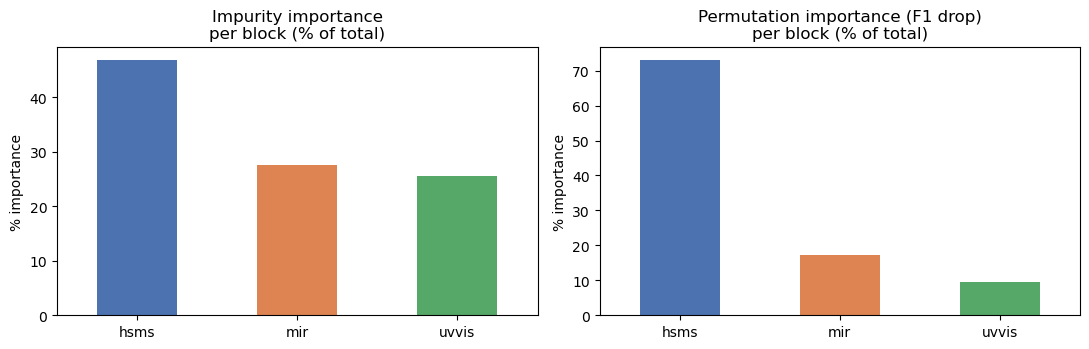

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, title in zip(axes, ["impurity", "permutation"],
                          ["Impurity importance", "Permutation importance (F1 drop)"]):
    per_block_pct[col].plot.bar(ax=ax, color=["#4c72b0", "#dd8452", "#55a868"])
    ax.set_title(f"{title}\nper block (% of total)")
    ax.set_ylabel("% importance"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## Next steps

- Classifier sweep complete: 02a PLS-DA 0.765, 02b LDA 0.755, 02c QDA 0.688,
  02d SVM-RBF 0.777, 02e RF 0.782 — all within noise above 0.755. The ceiling is
  **feature-bound**, not classifier-bound.
- **Feature track, HS-MS first.** The importances above make HS-MS the priority
  for region / preprocessing refinement (its 100–125 window drives the result),
  with MIR/UV-vis as complementary blocks. Variable selection (iPLS, sparse-PLS,
  GA) on HS-MS is the highest-value next experiment.